In [26]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [27]:
class MNISTCSVDataset(Dataset):
    def __init__(self, csv_path):
        data = pd.read_csv(csv_path, header=None)

        # 第一列是 label
        self.labels = torch.tensor(data.iloc[:, 0].values, dtype=torch.long)

        # 后面 784 列是 pixel
        images = data.iloc[:, 1:].values

        # 转成 float32，并归一化到 [0, 1]
        self.images = torch.tensor(images, dtype=torch.float32).reshape((-1, 1, 28, 28)) / 255.0

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = self.images[idx]  # shape: [784]
        y = self.labels[idx]  # scalar label
        return x, y
data_path = "C:/code/dataset/MNIST/MNIST_CSV/MNIST_CSV/MNIST_CSV"
train_csv = data_path + "/" + "mnist_train.csv"
test_csv = data_path + "/" + "mnist_test.csv"

In [28]:
train_dataset = MNISTCSVDataset(train_csv)
test_dataset = MNISTCSVDataset(test_csv)
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

x_batch, y_batch = next(iter(train_loader))
print("x_batch shape:", x_batch.shape)
print("y_batch shape:", y_batch.shape)

Train size: 60000
Test size: 10000
x_batch shape: torch.Size([64, 1, 28, 28])
y_batch shape: torch.Size([64])


In [ ]:
class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv_layers = nn.Sequential(
            # 输入: [batch_size, 1, 28, 28]
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            # 现在: [batch_size, 16, 14, 14]
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            # 现在: [batch_size, 32, 7, 7]
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.classifier(x)
        return x

In [30]:
model = MLP().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

MLP(
  (conv_layers): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [31]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        # forward
        logits = model(x)
        loss = criterion(logits, y)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 统计 loss
        batch_size = x.size(0)
        total_loss += loss.item() * batch_size

        # 统计 accuracy
        preds = logits.argmax(dim=1)
        total_correct += (preds == y).sum().item()
        total_samples += batch_size

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc


def evaluate(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = criterion(logits, y)

            batch_size = x.size(0)
            total_loss += loss.item() * batch_size

            preds = logits.argmax(dim=1)
            total_correct += (preds == y).sum().item()
            total_samples += batch_size

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc

In [32]:
num_epochs = 20

train_losses = []
train_accs = []
test_losses = []
test_accs = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}"
    )

Epoch [1/20] Train Loss: 0.6522, Train Acc: 0.7880 | Test Loss: 0.2574, Test Acc: 0.9197
Epoch [2/20] Train Loss: 0.2035, Train Acc: 0.9382 | Test Loss: 0.1610, Test Acc: 0.9471
Epoch [3/20] Train Loss: 0.1380, Train Acc: 0.9574 | Test Loss: 0.0970, Test Acc: 0.9697
Epoch [4/20] Train Loss: 0.1068, Train Acc: 0.9672 | Test Loss: 0.0788, Test Acc: 0.9753
Epoch [5/20] Train Loss: 0.0852, Train Acc: 0.9735 | Test Loss: 0.0801, Test Acc: 0.9736
Epoch [6/20] Train Loss: 0.0707, Train Acc: 0.9783 | Test Loss: 0.0591, Test Acc: 0.9805
Epoch [7/20] Train Loss: 0.0608, Train Acc: 0.9807 | Test Loss: 0.0542, Test Acc: 0.9822
Epoch [8/20] Train Loss: 0.0565, Train Acc: 0.9825 | Test Loss: 0.0570, Test Acc: 0.9823
Epoch [9/20] Train Loss: 0.0479, Train Acc: 0.9851 | Test Loss: 0.0387, Test Acc: 0.9873
Epoch [10/20] Train Loss: 0.0424, Train Acc: 0.9869 | Test Loss: 0.0415, Test Acc: 0.9866
Epoch [11/20] Train Loss: 0.0400, Train Acc: 0.9873 | Test Loss: 0.0293, Test Acc: 0.9893
Epoch [12/20] Train

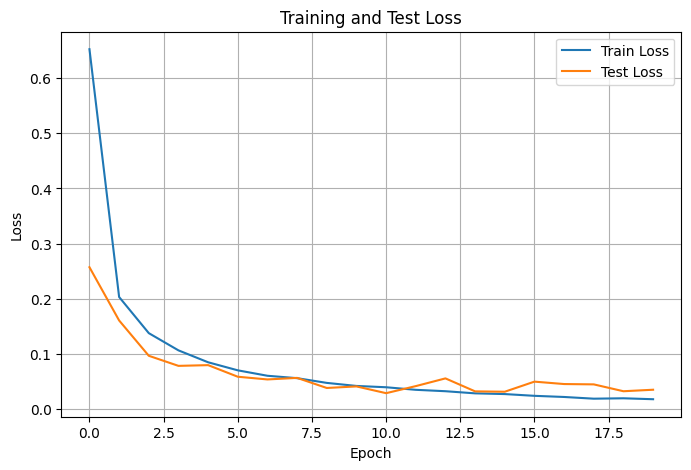

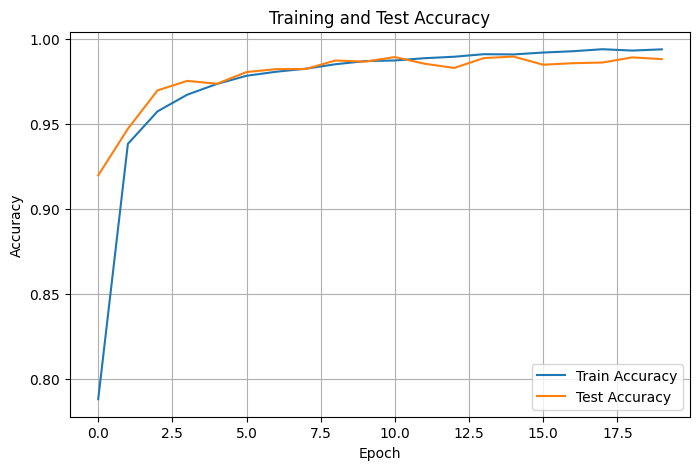

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(train_accs, label="Train Accuracy")
plt.plot(test_accs, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()